In [1]:
# === 0. SETUP & IMPORTS ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import textwrap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.graph_objects as go  # for Sankey


In [ ]:
# === 1. LOAD DATA & CLEAN COLUMNS ===

base_path = "/Users/christiangroeger/Desktop/KI-Campus/surveys/"

df_start = pd.read_csv(base_path + "Umfrage_zu_Kursbeginn.csv")
df_end   = pd.read_csv(base_path + "Umfrage_zum_Kursende.csv")

# Clean column names (remove spaces)
df_start.columns = df_start.columns.str.strip().str.replace(" ", "_")
df_end.columns   = df_end.columns.str.strip().str.replace(" ", "_")

df_start.head()


In [3]:
print(df_start.columns)
print(df_end.columns)

Index(['Response', 'Submitted_on:', 'Institution', 'Department', 'Course',
       'Group', 'ID', 'Full_name', 'Username',
       'Q01_Question_1->Ich_interessiere_mich_für_das_Kursthema.',
       'Q01_Question_1->Ich_möchte_ein_Zertifikat_erhalten_(zB._Teilnahmebestätigung,_Leistungsnachweis).',
       'Q01_Question_1->Es_ist_Teil_meines_Universitätsstudiums_(z._B._ein_Pflicht-_oder_Wahlfach).',
       'Q01_Question_1->Ich_möchte_mein_Wissen_zur_beruflichen_Weiterentwicklung_vertiefen.',
       'Q01_Question_1->Ich_strebe_eine_berufliche_Höherqualifizierung_oder_einen_Berufswechsel_an.',
       'Q01_Question_1->Ich_verfüge_bereits_über_Vorkenntnisse_und_möchte_diese_auffrischen_oder_erweitern.',
       'Q01_Question_1->Ich_möchte_die_Kursmaterialien_in_meinem_eigenen_Unterricht_verwenden.',
       'Q01_Question_1->Sonstiges', 'Q02_Question_2->Grundlagen_der_KI',
       'Q02_Question_2->Maschinelles_Lernen',
       'Q02_Question_2->Natural_Language_Processing_/_Large_Language_Models_(NL

In [4]:
# === 2. MAP Q-BLOCKS TO REAL QUESTIONS ===

start_questions = np.array([
    "1. Was motiviert dich diesen Kurs zu belegen?",
    "2. Welche zentralen KI-Technologien oder -Methoden interessieren dich?",
    "3. Welche Anwendungsgebiete oder gesellschaftlichen Aspekte der KI interessieren dich?",
    "4. Mit welchem Geschlecht identifizierst du dich?",
    "5. Welchen höchsten Schul- oder Berufsabschluss hast du erworben?",
    "6. Falls du derzeit berufstätig oder in Ausbildung bist, in welchem Bereich arbeitest du?"
])

end_questions = np.array([
    "1. Wie war dein Gesamteindruck vom Kurs?",
    "2. Würdest du den Kurs an jemanden empfehlen?",
    "3. Falls Nein: Warum nicht?",
    "4. Hast du deine persönlichen Lernziele erreicht?",
    "5. Wie schätzt du dein Wissen VOR dem Kurs ein?",
    "6. Wie schätzt du dein Wissen NACH dem Kurs ein?",
    "7. Welche Kurselemente haben dein Lernen unterstützt?",
    "8. Wie hilfreich war der KI-Chatbot?",
    "9. Wie hast du den KI-Chatbot genutzt?",
    "10. Mit welchem Geschlecht identifizierst du dich?",
    "11. Welchen höchsten Schul- oder Berufsabschluss hast du erworben?",
    "12. Falls du berufstätig bist: In welchem Bereich arbeitest du?"
])

start_mapping = {f"Q{str(i+1).zfill(2)}": q for i, q in enumerate(start_questions)}
end_mapping   = {f"Q{str(i+1).zfill(2)}": q for i, q in enumerate(end_questions)}


In [5]:
# === 3. GROUP ANSWER COLUMNS ===

def get_qcode(col):
    m = re.match(r"(Q\d{2})_", col)
    return m.group(1) if m else None

def group_questions(df, mapping):
    groups = {}
    for col in df.columns:
        qcode = get_qcode(col)
        if qcode in mapping:
            qtext = mapping[qcode]
            groups.setdefault(qtext, []).append(col)
    return groups

start_groups = group_questions(df_start, start_mapping)
end_groups   = group_questions(df_end, end_mapping)


In [6]:
# === 4. EDA: FREQUENCY TABLES 

def clean_label(label):
    # Remove prefix like "Q01_Question_1->"
    label = re.sub(r"Q\d{2}_Question_\d+->", "", label)
    # Replace underscores with spaces
    label = label.replace("_", " ")
    return label


def summarise(df, groups):
    summary = {}
    for question, cols in groups.items():
        counts = df[cols].apply(lambda x: (x == 1).sum()).sort_values(ascending=False)
        summary[question] = counts
    return summary

start_summary = summarise(df_start, start_groups)
end_summary   = summarise(df_end, end_groups)


In [7]:
# === 5. PLOTTING ===

sns.set_theme(style="whitegrid", font_scale=1.1)

def plot_question(summary_dict, title_prefix=""):
    for question, counts in summary_dict.items():

        plt.figure(figsize=(12, max(4, len(counts) * 0.6)))

        # CLEAN LABELS HERE
        labels = [textwrap.fill(clean_label(lbl), width=40) for lbl in counts.index]

        sns.barplot(x=counts.values, y=labels, orient="h")

        plt.title(f"{title_prefix}{question}")
        plt.xlabel("Anzahl der Nennungen")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()


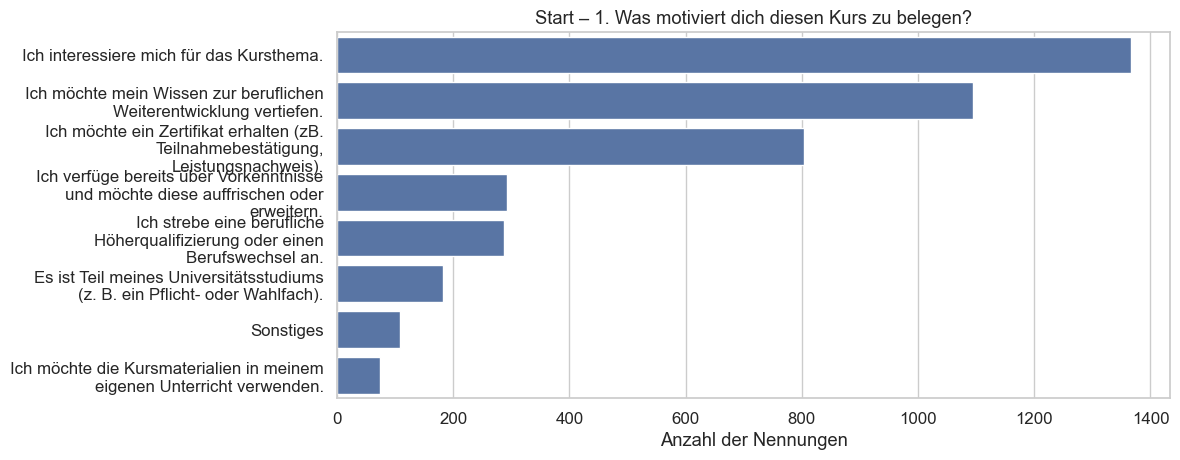

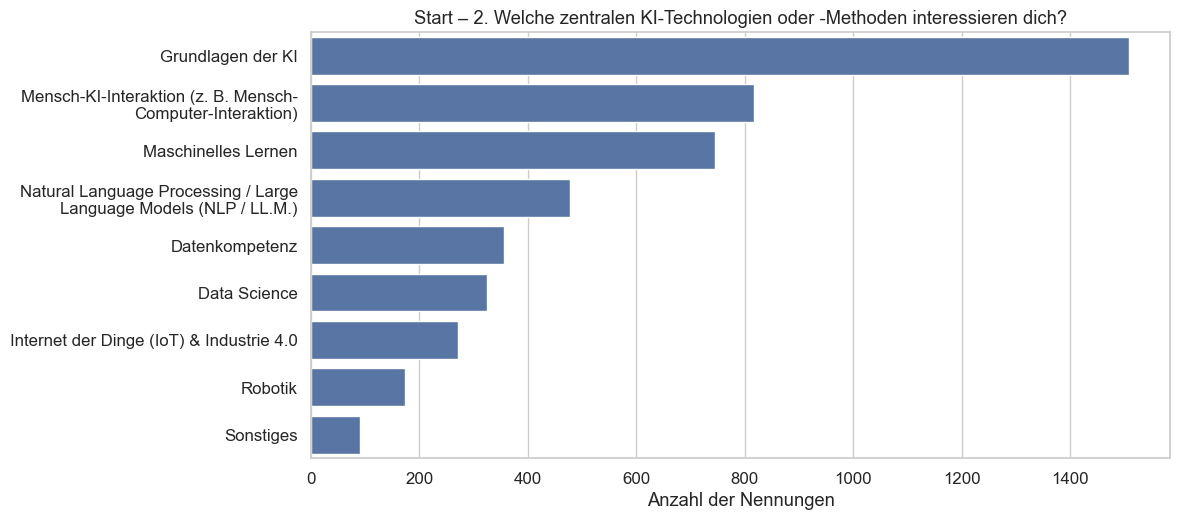

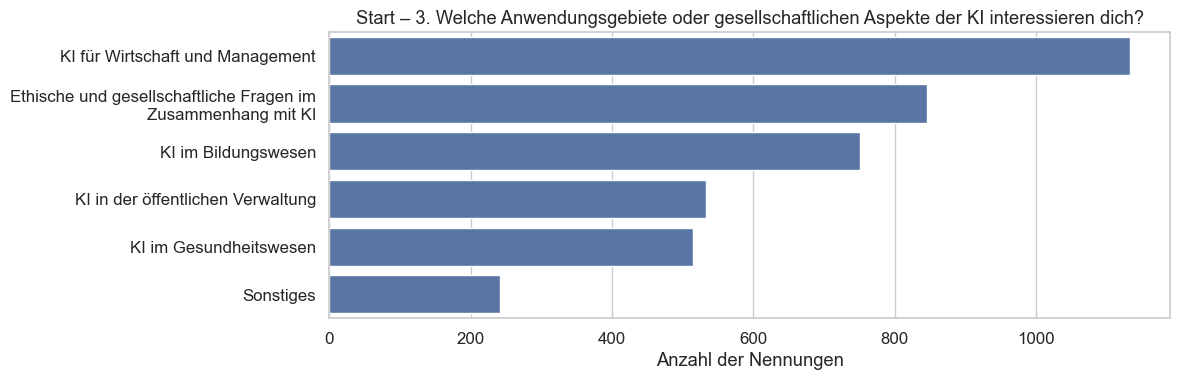

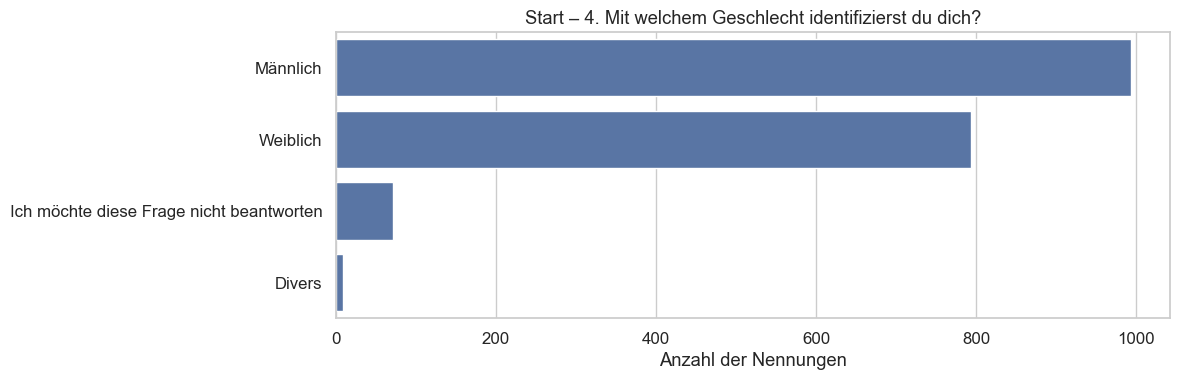

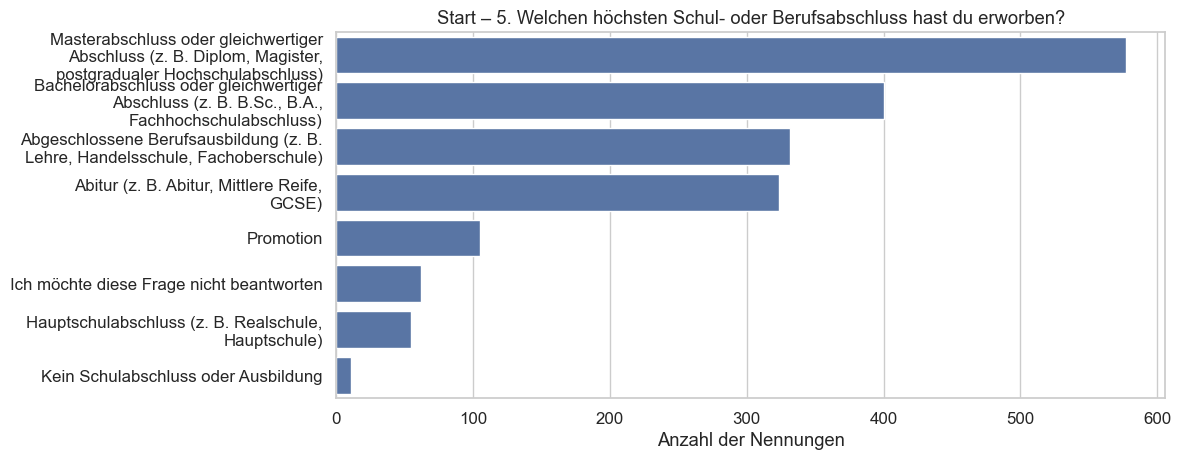

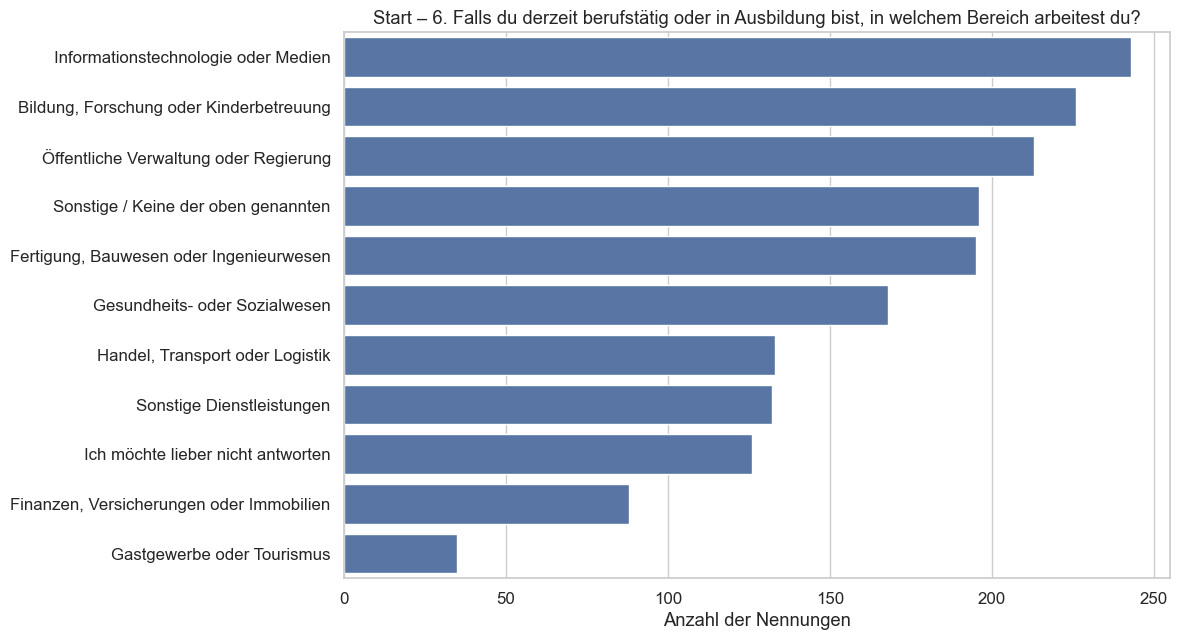

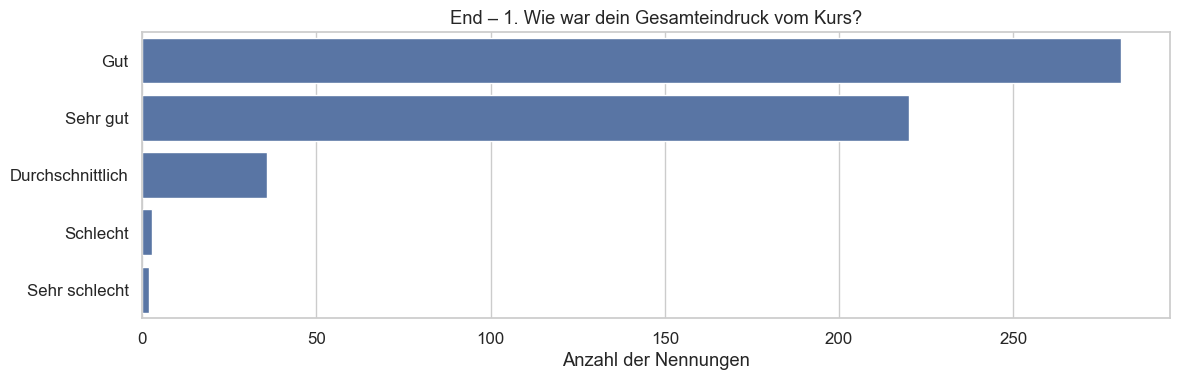

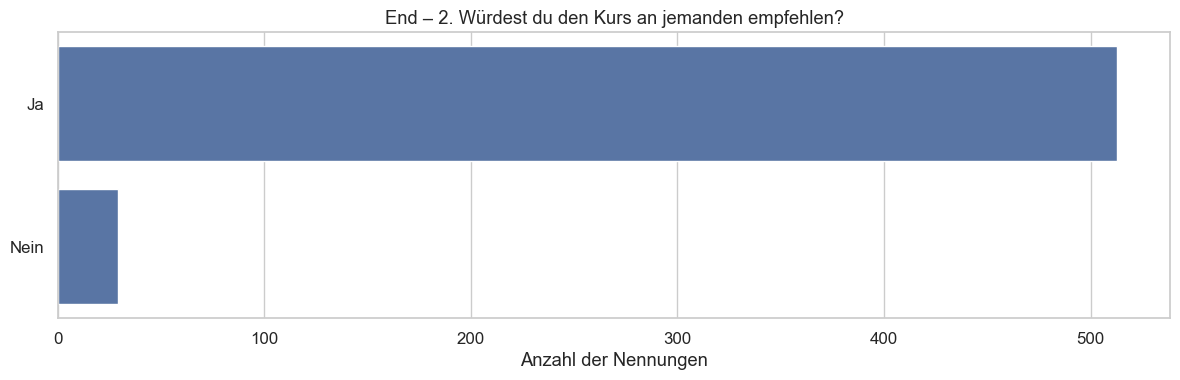

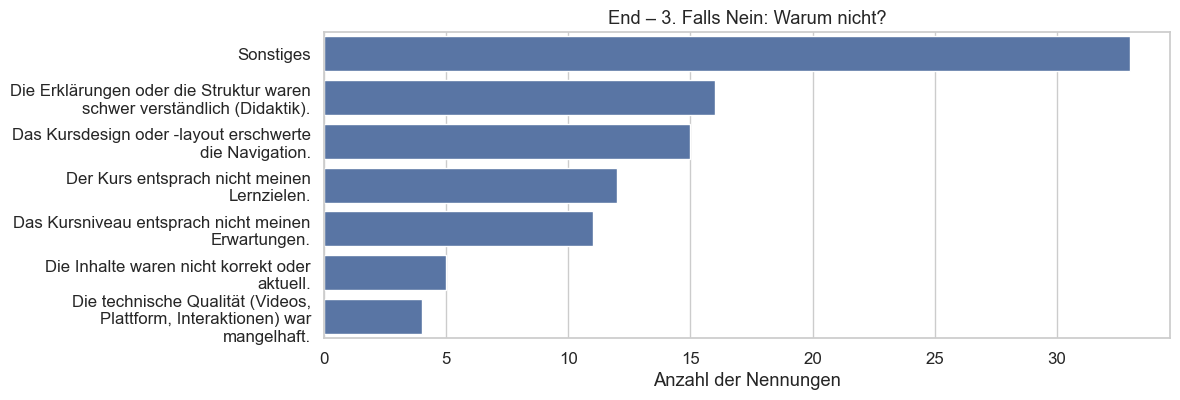

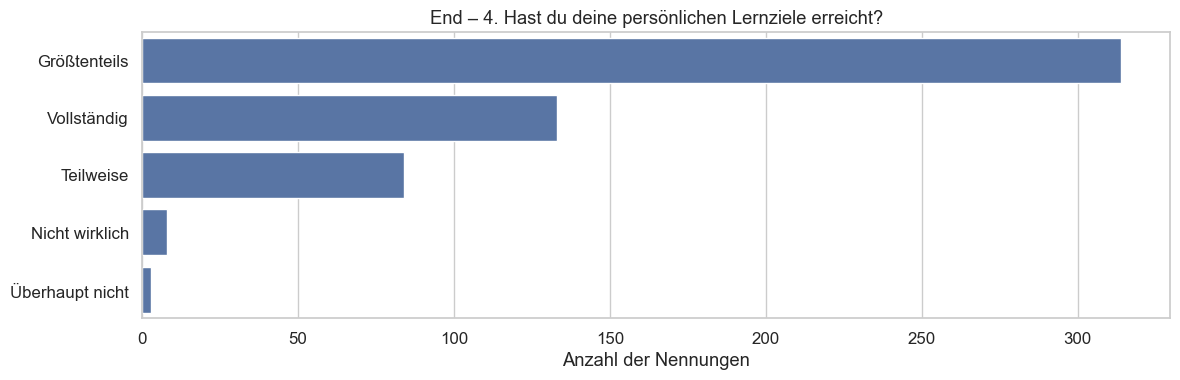

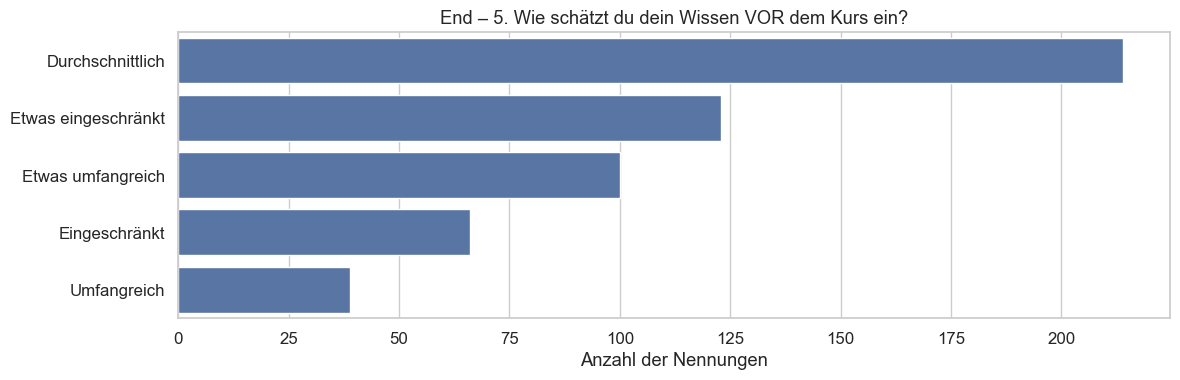

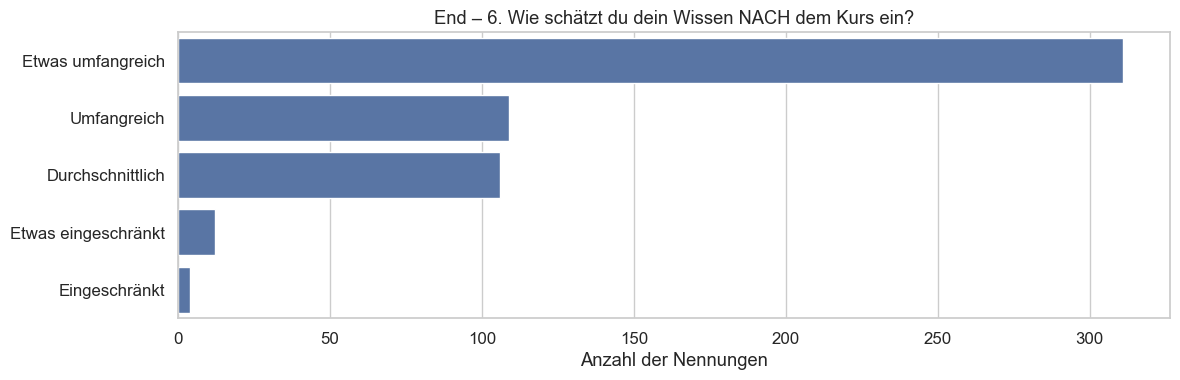

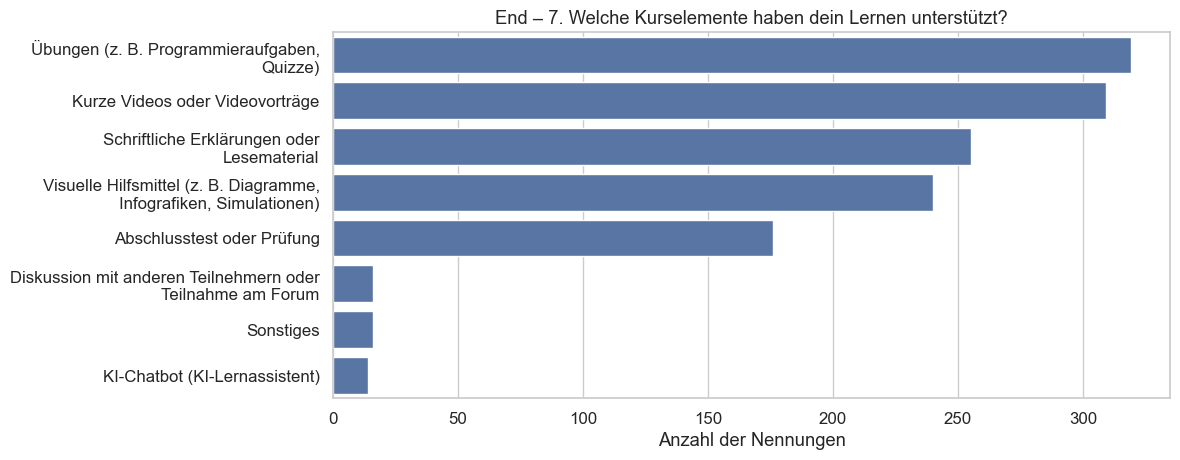

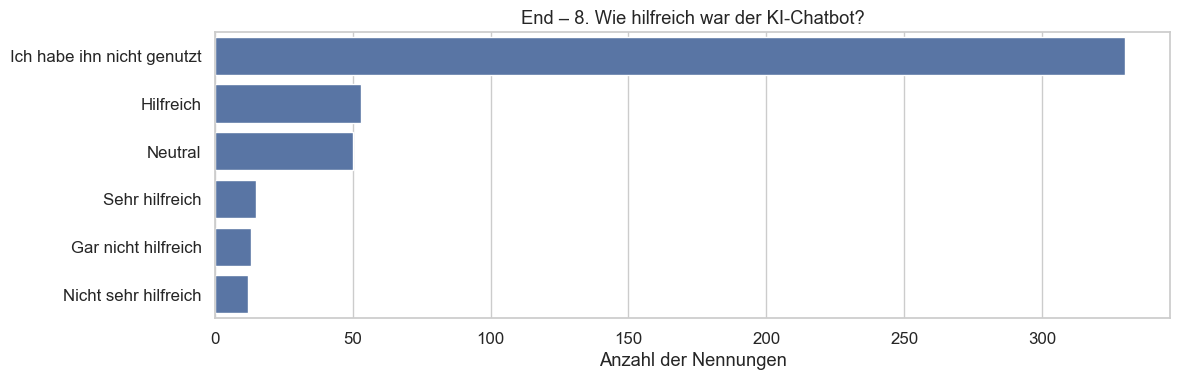

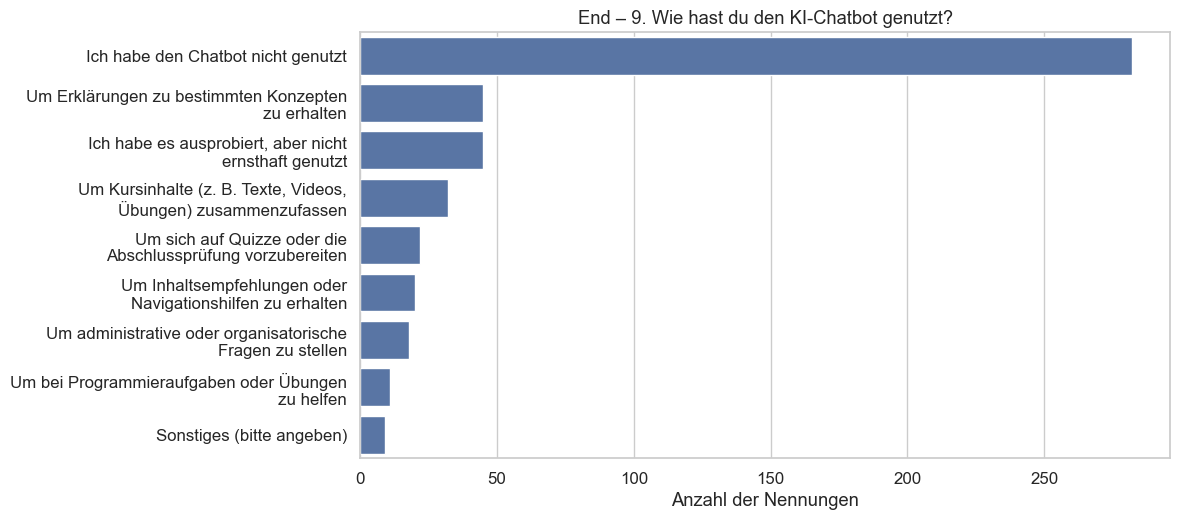

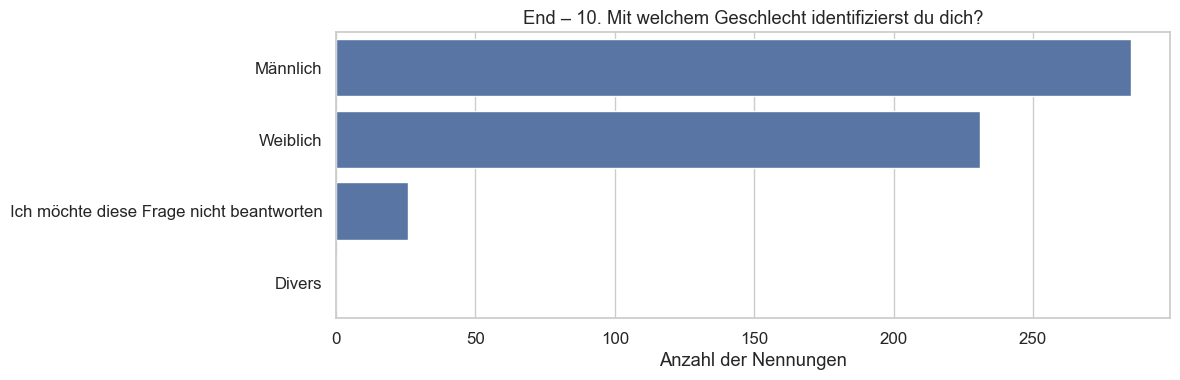

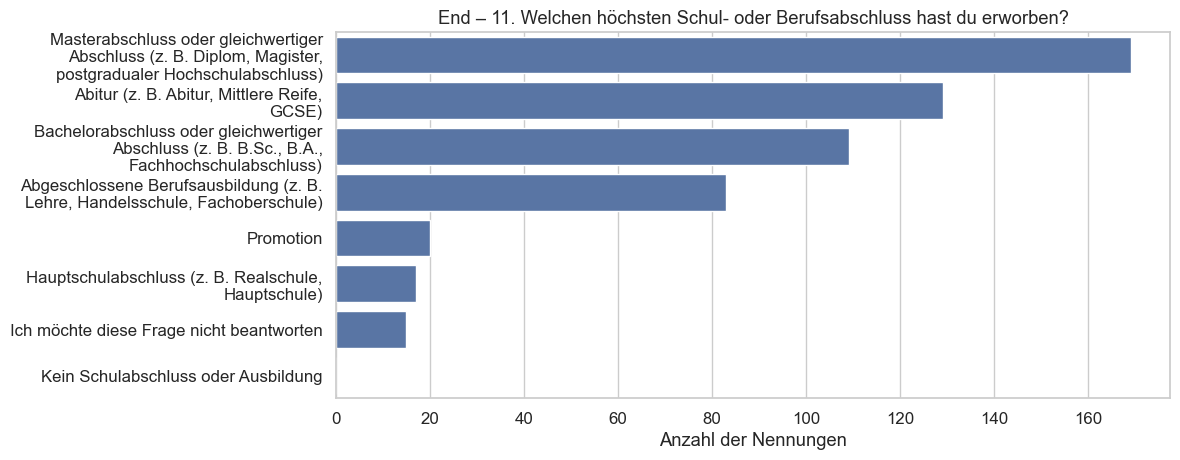

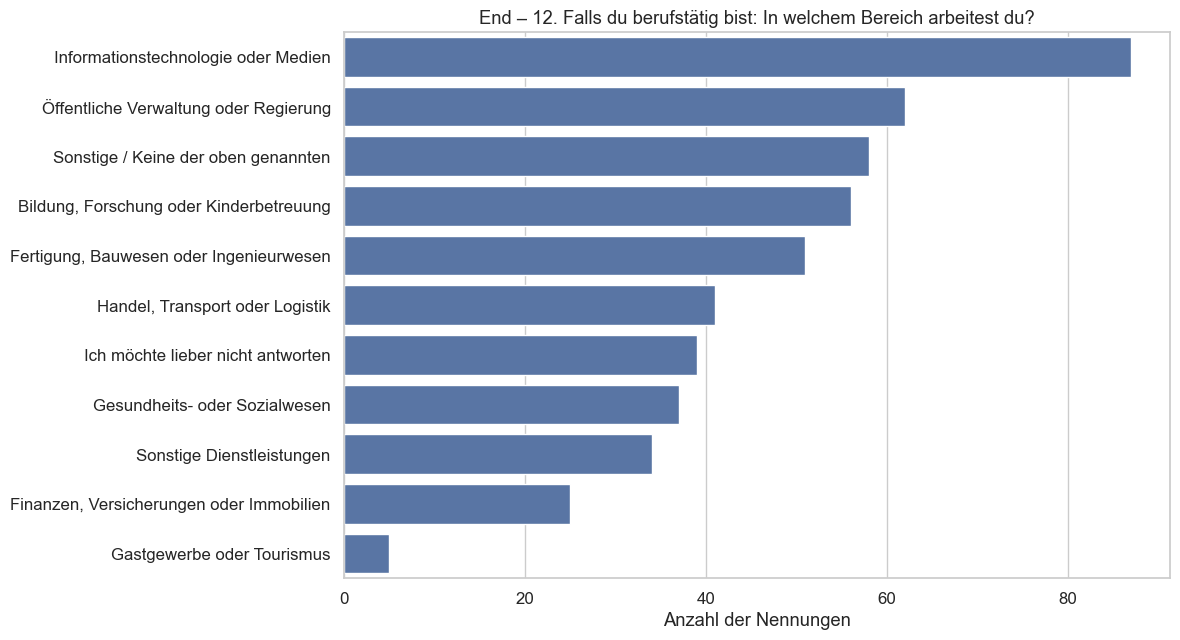

In [8]:
# 6. DISPLAY START + END SURVEY PLOTS
plot_question(start_summary, title_prefix="Start – ")
plot_question(end_summary, title_prefix="End – ")


In [9]:
# 7. MERGE START + END ON 'ID'
df_merged = pd.merge(df_start, df_end, on="ID", how="inner", suffixes=("_start", "_end"))
df_merged.shape


(466, 138)

In [10]:
# 8. BEFORE–AFTER KNOWLEDGE 

# Get knowledge-before and knowledge-after columns
knowledge_before_cols = end_groups["5. Wie schätzt du dein Wissen VOR dem Kurs ein?"]
knowledge_after_cols  = end_groups["6. Wie schätzt du dein Wissen NACH dem Kurs ein?"]




def collapse_knowledge(df, cols):
    # Each row selects exactly one knowledge option = 1
    melted = df[cols]
    return melted.idxmax(axis=1).str.replace("Q.._Question_._->", "", regex=True)

def clean_answer_text(text):
    # Remove the prefix "QXX_Question_X->"
    text = re.sub(r"Q\d{2}_Question_\d+->", "", text)
    # Replace underscores with spaces
    text = text.replace("_", " ")
    return text



# ---- Collapse BEFORE / AFTER
df_end["knowledge_before"] = collapse_knowledge(df_end, knowledge_before_cols)
df_end["knowledge_after"]  = collapse_knowledge(df_end, knowledge_after_cols)

# ---- Clean labels
df_end["knowledge_before_clean"] = df_end["knowledge_before"].apply(clean_answer_text)
df_end["knowledge_after_clean"]  = df_end["knowledge_after"].apply(clean_answer_text)



In [11]:
# ============================================================
# How does participants’ self-assessed knowledge level change from before the course to after the course?
# ============================================================


print("=" * 80)
#print("FORSCHUNGSFRAGE")
print(
    "How does participants’ self-assessed knowledge level change from before the course to after the course?"
)
print("=" * 80, "\n")



How does participants’ self-assessed knowledge level change from before the course to after the course?



In [12]:
# before-after table

transition_clean = pd.crosstab(
    df_end["knowledge_before_clean"],
    df_end["knowledge_after_clean"]
)

# Convert counts into row-wise percentages
transition_pct = transition_clean.div(transition_clean.sum(axis=1), axis=0) * 100
transition_pct = transition_pct.round(1)
transition_pct


knowledge_after_clean,Durchschnittlich,Eingeschränkt,Etwas eingeschränkt,Etwas umfangreich,Umfangreich
knowledge_before_clean,,,,,
Durchschnittlich,13.6,0.0,0.5,72.9,13.1
Eingeschränkt,40.9,4.5,15.2,33.3,6.1
Etwas eingeschränkt,27.6,0.0,0.8,63.4,8.1
Etwas umfangreich,12.0,1.0,0.0,44.0,43.0
Umfangreich,10.3,0.0,0.0,28.2,61.5


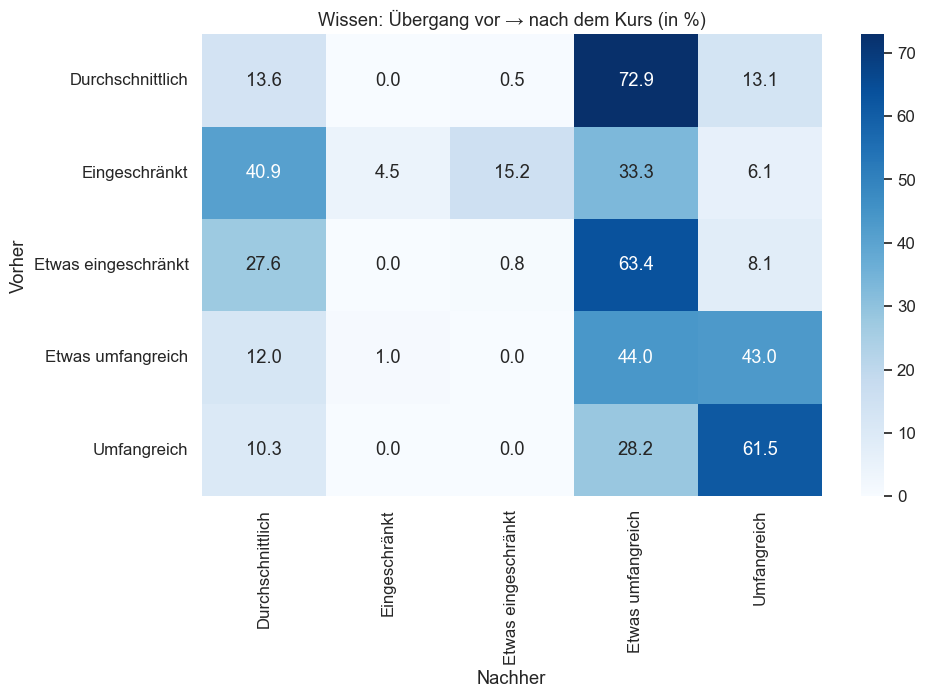

In [13]:
# heatmap 
plt.figure(figsize=(10,6))
sns.heatmap(transition_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Wissen: Übergang vor → nach dem Kurs (in %)")
plt.xlabel("Nachher")
plt.ylabel("Vorher")
plt.show()


In [14]:
import plotly
import sys
import plotly.io as pio
import plotly.graph_objects as go

# for safari if sankey does not work
pio.renderers.default = "iframe"

In [15]:
# 8B. SANKEY DIAGRAM



import plotly.graph_objects as go

# 2. All unique labels (before + after)
labels = list(transition_clean.index) + [
    c for c in transition_clean.columns if c not in transition_clean.index
]
label_to_id = {lab: i for i, lab in enumerate(labels)}

# 3. Build source/target/value lists
sources, targets, values = [], [], []

for before_label, row in transition_clean.iterrows():
    for after_label, val in row.items():
        if val > 0:
            sources.append(label_to_id[before_label])
            targets.append(label_to_id[after_label])
            values.append(int(val))

# 4. Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=20,
        thickness=20
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(title_text="Wissen vor → nach dem Kurs", font_size=12)
fig.show()



In [16]:
# normalise gender


gender_cols = [
    c for c in df_end.columns
    if c.startswith("Q10_Question_10->")
]
gender_cols

# use collapse function again
def collapse_single_choice(df, cols):
    """
    Collapses one-hot encoded single-choice questions
    into a single categorical column.
    """
    return (
        df[cols]
        .idxmax(axis=1)
        .str.replace("Q10_Question_10->", "", regex=False)
        .str.replace("_", " ")
    )

# create gender column
df_start["gender_clean"] = collapse_single_choice(df_end, gender_cols)

df_start["gender_clean"].value_counts(dropna=False)


gender_clean
NaN                                         1324
Männlich                                     285
Weiblich                                     231
Ich möchte diese Frage nicht beantworten      26
Name: count, dtype: int64

In [17]:
# ============================================================
# Do course motivations differ between female and male participants?
# ============================================================


print("=" * 80)
#print("FORSCHUNGSFRAGE")
print(
    "Do course motivations differ between female and male participants?"
)
print("=" * 80, "\n")


# goal: relative heatmap

Do course motivations differ between female and male participants?



In [18]:
# Select motivation columns (multiple-choice question Q01)
motivation_cols = [
    c for c in df_start.columns
    if c.startswith("Q01_Question_1->")
]



print(len(motivation_cols), "Motivations-Spalten gefunden")
motivation_cols


8 Motivations-Spalten gefunden


['Q01_Question_1->Ich_interessiere_mich_für_das_Kursthema.',
 'Q01_Question_1->Ich_möchte_ein_Zertifikat_erhalten_(zB._Teilnahmebestätigung,_Leistungsnachweis).',
 'Q01_Question_1->Es_ist_Teil_meines_Universitätsstudiums_(z._B._ein_Pflicht-_oder_Wahlfach).',
 'Q01_Question_1->Ich_möchte_mein_Wissen_zur_beruflichen_Weiterentwicklung_vertiefen.',
 'Q01_Question_1->Ich_strebe_eine_berufliche_Höherqualifizierung_oder_einen_Berufswechsel_an.',
 'Q01_Question_1->Ich_verfüge_bereits_über_Vorkenntnisse_und_möchte_diese_auffrischen_oder_erweitern.',
 'Q01_Question_1->Ich_möchte_die_Kursmaterialien_in_meinem_eigenen_Unterricht_verwenden.',
 'Q01_Question_1->Sonstiges']

In [19]:
# heatmap 

# define category mapping
label_mapping_substrings = {
    "Ich_interessiere_mich_für_das_Kursthema": "Interesse am Thema",
    "Ich_möchte_ein_Zertifikat_erhalten_(zB._Teilnahmebestätigung,_Leistungsnachweis).": "Zertifikat",
    "Es_ist_Teil_meines_Universitätsstudiums": "Pflicht-/Wahlfach",
    "Ich_möchte_mein_Wissen_zur_beruflichen_Weiterentwicklung_vertiefen": "Berufliche Weiterentwicklung",
    "Ich_strebe_eine_berufliche_Höherqualifizierung_oder_einen_Berufswechsel_an": "Höherqualifizierung / Wechsel",
    "Ich_verfüge_bereits_über_Vorkenntnisse_und_möchte_diese_auffrischen_oder_erweitern": "Vorkenntnisse auffrischen",
    "Ich_möchte_die_Kursmaterialien_in_meinem_eigenen_Unterricht_verwenden": "Materialien im Unterricht",
    "Sonstiges": "Sonstiges"
}

# Aggregate motivation selections by gender (absolute counts)
heat = (
    df_start
    .loc[df_start["gender_clean"].isin(["Weiblich", "Männlich"])]
    .groupby("gender_clean")[motivation_cols]
    .sum()
)

# Remove question prefix
heat.columns = heat.columns.str.replace("Q01_Question_1->", "", regex=False)

# Convert to row-wise proportions
heat_rel = heat.div(heat.sum(axis=1), axis=0)

# mapping function
def map_labels_robust(columns, mapping):
    new_cols = []
    for col in columns:
        mapped = col
        for key, value in mapping.items():
            if key in col:
                mapped = value
                break
        new_cols.append(mapped)
    return new_cols

# mapping used
heat_rel.columns = map_labels_robust(
    heat_rel.columns,
    label_mapping_substrings
)


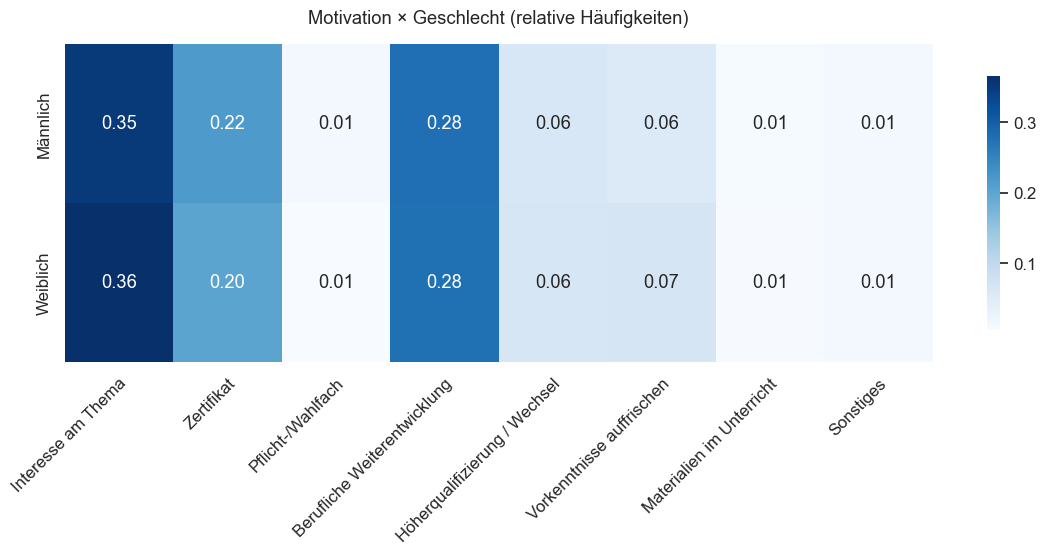

In [20]:
from textwrap import fill






plt.figure(figsize=(14, 6))

ax = sns.heatmap(
    heat_rel,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"shrink": 0.8}
)

ax.set_xticklabels(
    heat_rel.columns,
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

plt.title("Motivation × Geschlecht (relative Häufigkeiten)", pad=15)
plt.ylabel("")
plt.xlabel("")

plt.subplots_adjust(bottom=0.35)
plt.show()


In [21]:
# REASEARCH QUESTION

# ============================================================
# Are there distinct groups of participants with similar end-of-course response patterns?
# ============================================================


print("=" * 80)
#print("FORSCHUNGSFRAGE")
print(
    "Are there distinct groups of participants with similar end-of-course response patterns?"
)
print("=" * 80, "\n")




Are there distinct groups of participants with similar end-of-course response patterns?



In [22]:
# ============================================================
# PCA + K-MEANS CLUSTERING OF END-OF-COURSE RESPONSES
#
# Research question:
# Are there distinct groups of participants with similar
# end-of-course multi-select response patterns?
#
# Method:
# - One-hot encoded end-survey responses as features
# - Standardization
# - PCA for dimensionality reduction and visualization
# - K-Means clustering to identify participant profiles
#
# Goal:
# Exploratory identification of latent learner profiles
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


In [23]:

# Load data
df_end_raw = pd.read_csv(base_path + "Umfrage_zum_Kursende.csv")
df_cluster = df_end_raw.copy()

# Select multi-select end-survey columns as features
cols_multi = [
    c for c in df_cluster.columns
    if c.startswith("Q") and "->" in c
]

print("Number of participants:", df_cluster.shape[0])
print("Number of feature columns:", len(cols_multi))

X = df_cluster[cols_multi].fillna(0)

assert X.shape[0] > 0, "No samples available for PCA"
assert X.shape[1] > 1, "Not enough features for PCA"



Number of participants: 542
Number of feature columns: 75


In [24]:
# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ------------------------------------------------------------
# PCA (for structure + visualization)
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


# ------------------------------------------------------------
# K-Means clustering (exploratory)
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_pca)

df_cluster["cluster"] = clusters

Explained variance ratio: [0.06503851 0.04998082]
Total explained variance: 0.11501932505250331


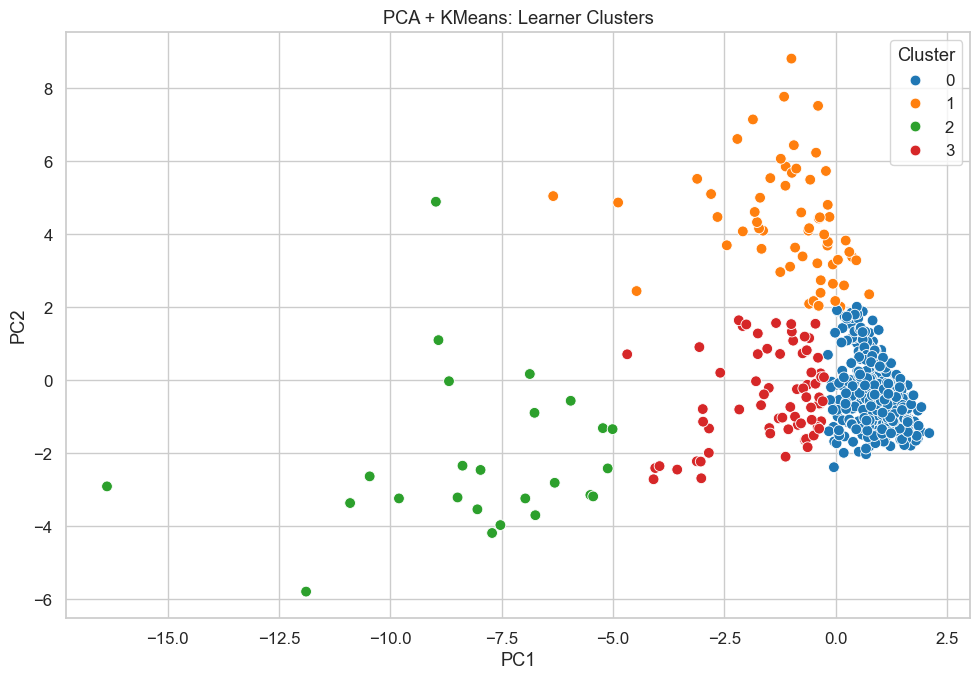


Cluster sizes:
cluster
0    385
1     61
2     25
3     71
Name: count, dtype: int64

Top features for cluster 0


Q02_Question 2->Ja                                             1.000000
Q08_Question 8->Ich habe ihn nicht genutzt                     0.735065
Q06_Question 6->Etwas umfangreich                              0.657143
Q04_Question 4->Größtenteils                                   0.644156
Q09_Question 9->Ich habe den Chatbot nicht genutzt             0.620779
Q07_Question 7->Übungen (z. B. Programmieraufgaben, Quizze)    0.610390
Q07_Question 7->Kurze Videos oder Videovorträge                0.607792
Q10_Question 10->Männlich                                      0.542857
Name: 0, dtype: float64


Top features for cluster 1


Q02_Question 2->Ja                                                    1.000000
Q08_Question 8->Hilfreich                                             0.590164
Q04_Question 4->Größtenteils                                          0.573770
Q10_Question 10->Männlich                                             0.573770
Q07_Question 7->Kurze Videos oder Videovorträge                       0.557377
Q07_Question 7->Übungen (z. B. Programmieraufgaben, Quizze)           0.540984
Q09_Question 9->Um Erklärungen zu bestimmten Konzepten zu erhalten    0.540984
Q01_Question 1->Sehr gut                                              0.524590
Name: 1, dtype: float64


Top features for cluster 2


Q02_Question 2->Nein                                  0.92
Q01_Question 1->Durchschnittlich                      0.52
Q06_Question 6->Durchschnittlich                      0.52
Q03_Question 3->Sonstiges                             0.48
Q08_Question 8->Ich habe ihn nicht genutzt            0.48
Q10_Question 10->Männlich                             0.44
Q09_Question 9->Ich habe den Chatbot nicht genutzt    0.44
Q05_Question 5->Durchschnittlich                      0.44
Name: 2, dtype: float64


Top features for cluster 3


Q02_Question 2->Ja                                             0.915493
Q07_Question 7->Übungen (z. B. Programmieraufgaben, Quizze)    0.605634
Q01_Question 1->Gut                                            0.591549
Q04_Question 4->Teilweise                                      0.507042
Q08_Question 8->Ich habe ihn nicht genutzt                     0.492958
Q07_Question 7->Kurze Videos oder Videovorträge                0.464789
Q07_Question 7->Schriftliche Erklärungen oder Lesematerial     0.450704
Q09_Question 9->Ich habe den Chatbot nicht genutzt             0.436620
Name: 3, dtype: float64

In [25]:
# ------------------------------------------------------------
# Visualization in PCA space
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters,
    palette="tab10",
    s=60
)

plt.title("PCA + KMeans: Learner Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Cluster sizes (sanity check)
# ------------------------------------------------------------
print("\nCluster sizes:")
print(df_cluster["cluster"].value_counts().sort_index())


# ------------------------------------------------------------
# Cluster profiles
# ------------------------------------------------------------
# Mean response per feature per cluster
cluster_profiles = (
    df_cluster
    .groupby("cluster")[cols_multi]
    .mean()
)


# Show top features per cluster
TOP_K = 8

for c in cluster_profiles.index:
    print(f"\nTop features for cluster {c}")
    display(
        cluster_profiles
        .loc[c]
        .sort_values(ascending=False)
        .head(TOP_K)
    )




In [26]:
# inspect cluster sizes
df_cluster["cluster"].value_counts()

# characterize clusters
cluster_profiles = (
    df_cluster
    .groupby("cluster")[cols_multi]
    .mean()
)
cluster_profiles

,Q01_Question 1->Sehr gut,Q01_Question 1->Gut,Q01_Question 1->Durchschnittlich,Q01_Question 1->Schlecht,Q01_Question 1->Sehr schlecht,Q02_Question 2->Ja,Q02_Question 2->Nein,Q03_Question 3->Die Inhalte waren nicht korrekt oder aktuell.,Q03_Question 3->Die Erklärungen oder die Struktur waren schwer verständlich (Didaktik).,Q03_Question 3->Das Kursdesign oder -layout erschwerte die Navigation.,...,"Q12_Question 12->Handel, Transport oder Logistik",Q12_Question 12->Informationstechnologie oder Medien,"Q12_Question 12->Finanzen, Versicherungen oder Immobilien",Q12_Question 12->Gesundheits- oder Sozialwesen,"Q12_Question 12->Bildung, Forschung oder Kinderbetreuung",Q12_Question 12->Öffentliche Verwaltung oder Regierung,Q12_Question 12->Gastgewerbe oder Tourismus,Q12_Question 12->Sonstige Dienstleistungen,Q12_Question 12->Sonstige / Keine der oben genannten,Q12_Question 12->Ich möchte lieber nicht antworten
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.45974,0.527273,0.012987,0.00,0.00,1.000000,0.000000,0.002597,0.000000,0.000000,...,0.062338,0.168831,0.046753,0.083117,0.111688,0.135065,0.010390,0.059740,0.090909,0.041558
1,0.52459,0.475410,0.000000,0.00,0.00,1.000000,0.000000,0.032787,0.081967,0.065574,...,0.131148,0.098361,0.081967,0.032787,0.016393,0.065574,0.016393,0.081967,0.131148,0.114754
2,0.00000,0.280000,0.520000,0.12,0.08,0.080000,0.920000,0.040000,0.280000,0.320000,...,0.080000,0.160000,0.080000,0.040000,0.080000,0.160000,0.000000,0.040000,0.120000,0.160000
3,0.15493,0.591549,0.253521,0.00,0.00,0.915493,0.084507,0.014085,0.056338,0.042254,...,0.098592,0.169014,0.000000,0.028169,0.140845,0.028169,0.000000,0.070423,0.169014,0.169014


In [27]:
# naming clusters
cluster_names = {
    0: "Low-engagement learners",
    1: "Support-oriented learners",
    2: "Career-driven learners",
    3: "Exploratory / mixed learners"
}

df_cluster["cluster_label"] = df_cluster["cluster"].map(cluster_names)

# cluster stability check
def cluster_stability(X, n_clusters=4, runs=10):
    labels = []
    for seed in range(runs):
        km = KMeans(n_clusters=n_clusters, random_state=seed, n_init="auto")
        labels.append(km.fit_predict(X))
    
    scores = []
    for i in range(len(labels) - 1):
        scores.append(adjusted_rand_score(labels[i], labels[i+1]))
    
    return np.mean(scores), np.std(scores)

mean_ari, std_ari = cluster_stability(X_pca)
mean_ari, std_ari


(0.756815414079214, 0.2355087997637327)

In [28]:
# identify the correct columns
knowledge_before_cols = [
    c for c in df_cluster.columns
    if c.startswith("Q05_Question 5->")
]

knowledge_after_cols = [
    c for c in df_cluster.columns
    if c.startswith("Q06_Question 6->")
]

knowledge_before_cols, knowledge_after_cols

# collapse one-hot encoding into a asingle label
def collapse_onehot_to_label(df, cols):
    return (
        df[cols]
        .idxmax(axis=1)
        .str.replace(r"Q\d+_Question\s*\d+->", "", regex=True)
        .str.strip()
    )


df_cluster["knowledge_before_clean"] = collapse_onehot_to_label(
    df_cluster, knowledge_before_cols
)

df_cluster["knowledge_after_clean"] = collapse_onehot_to_label(
    df_cluster, knowledge_after_cols
)



In [29]:
# map to numeric scale
knowledge_map = {
    "Eingeschränkt": 1,
    "Etwas eingeschränkt": 2,
    "Durchschnittlich": 3,
    "Etwas umfangreich": 4,
    "Umfangreich": 5
}

df_cluster["kb_num"] = df_cluster["knowledge_before_clean"].map(knowledge_map)
df_cluster["ka_num"] = df_cluster["knowledge_after_clean"].map(knowledge_map)

df_cluster["knowledge_gain"] = df_cluster["ka_num"] - df_cluster["kb_num"]


# sanity check
df_cluster[[
    "knowledge_before_clean",
    "knowledge_after_clean",
    "kb_num",
    "ka_num",
    "knowledge_gain"
]].head()


,knowledge_before_clean,knowledge_after_clean,kb_num,ka_num,knowledge_gain
0,Etwas eingeschränkt,Durchschnittlich,2,3,1
1,Durchschnittlich,Etwas umfangreich,3,4,1
2,Durchschnittlich,Etwas umfangreich,3,4,1
3,Durchschnittlich,Etwas umfangreich,3,4,1
4,Durchschnittlich,Etwas umfangreich,3,4,1


In [32]:
# What is the knowledge gain by learner profile?

gain_by_cluster = (
    df_cluster
    .groupby("cluster_label")["knowledge_gain"]
    .mean()
    .sort_values(ascending=False)
)

display(gain_by_cluster)

cluster_label
Low-engagement learners         1.293506
Exploratory / mixed learners    0.676056
Support-oriented learners       0.606557
Career-driven learners          0.120000
Name: knowledge_gain, dtype: float64

In [31]:
# REASEARCH QUESTION

# ============================================================
# What is the knowledge gain by learner profile?
# ============================================================


print("=" * 80)
#print("FORSCHUNGSFRAGE")
print(
    "What is the knowledge gain by learner profile?"
)
print("=" * 80, "\n")




What is the knowledge gain by learner profile?



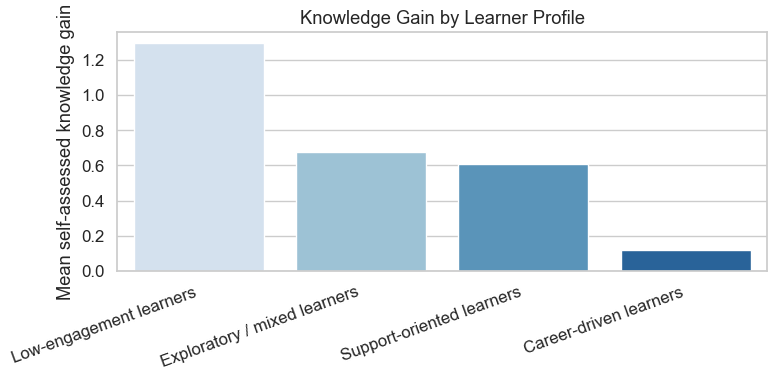

In [33]:


plt.figure(figsize=(8, 4))

sns.barplot(
    x=gain_by_cluster.index,
    y=gain_by_cluster.values,
    hue=gain_by_cluster.index,   # <-- add hue
    palette="Blues",
    legend=False                 # <-- no redundant legend

)

plt.ylabel("Mean self-assessed knowledge gain")
plt.xlabel("")
plt.title("Knowledge Gain by Learner Profile")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

